In [1]:
import sqlite3
import pandas as pd

In [2]:
DB_PATH = '../data/sharadar.db'

In [3]:
with sqlite3.connect(DB_PATH) as conn:
    tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name").fetchall()
tables

[('actions',),
 ('daily',),
 ('fundamentals',),
 ('sp500',),
 ('stocks',),
 ('tickers',)]

In [4]:
ticker = 'AAPL'
pd.read_sql_query('SELECT * FROM tickers WHERE ticker = ?', sqlite3.connect(DB_PATH), params=(ticker,))

,table,permaticker,ticker,name,exchange,isdelisted,category,cusips,siccode,sicsector,...,lastupdated,firstadded,firstpricedate,lastpricedate,firstquarter,lastquarter,secfilings,companysite,downloaded_at,sharadar_table
0,stocks,199059,AAPL,APPLE INC,NASDAQ,N,Domestic Common Stock,037833100,3571,Manufacturing,...,2026-09-04,2014-09-24,1986-01-01,2026-09-04,1992-12-31,2026-06-30,https://www.sec.gov/cgi-bin/browse-edgar?actio...,http://www.apple.com,2026-09-06T02:28:32.143702+00:00,tickers


In [5]:
pd.read_sql_query('SELECT * FROM actions WHERE ticker = ?', sqlite3.connect(DB_PATH), params=(ticker,)).head()

,date,action,ticker,name,value,contraticker,contraname,downloaded_at,sharadar_table
0,2000-06-21,split,AAPL,APPLE INC,2.00000,N/A,N/A,2026-09-06T02:28:49.466017+00:00,actions
1,2005-02-28,split,AAPL,APPLE INC,2.00000,N/A,N/A,2026-09-06T02:28:54.931992+00:00,actions
2,2007-01-10,namechangefrom,AAPL,APPLE INC,NaN,N/A,APPLE COMPUTER INC,2026-09-06T02:28:57.523353+00:00,actions
3,2007-01-10,namechangeto,AAPL,APPLE INC,NaN,N/A,APPLE INC,2026-09-06T02:28:57.523353+00:00,actions
4,2012-08-09,dividend,AAPL,APPLE INC,0.09464,N/A,N/A,2026-09-06T02:29:06.167001+00:00,actions


In [6]:
pd.read_sql_query('SELECT * FROM sp500 WHERE ticker = ?', sqlite3.connect(DB_PATH), params=(ticker,)).head()

,date,action,ticker,name,contraticker,contraname,note,downloaded_at,sharadar_table
0,2000-03-31,historical,AAPL,APPLE INC,N/A,N/A,None,2026-09-06T02:28:02.161584+00:00,sp500
1,2000-06-30,historical,AAPL,APPLE INC,N/A,N/A,None,2026-09-06T02:28:02.161584+00:00,sp500
2,2000-09-30,historical,AAPL,APPLE INC,N/A,N/A,None,2026-09-06T02:28:02.161584+00:00,sp500
3,2000-12-31,historical,AAPL,APPLE INC,N/A,N/A,None,2026-09-06T02:28:02.161584+00:00,sp500
4,2001-03-31,historical,AAPL,APPLE INC,N/A,N/A,None,2026-09-06T02:28:03.210678+00:00,sp500


In [7]:
pd.read_sql_query('SELECT * FROM fundamentals WHERE ticker = ?', sqlite3.connect(DB_PATH), params=(ticker,)).head()

,ticker,dimension,calendardate,date,reportperiod,fiscalperiod,lastupdated,accoci,assets,assetsavg,...,shareswadil,sps,tangibles,taxassets,taxexp,taxliabilities,tbvps,workingcapital,downloaded_at,sharadar_table
0,AAPL,MRQ,1999-12-31,2000-01-01,2000-01-01,2000-Q1,2026-07-31,1237000000,7586000000,NaN,...,19982704000,0.130,7586000000,131000000,91000000,907000000,0.421,2944000000,2026-09-06T02:41:03.341206+00:00,fundamentals
1,AAPL,MRT,1999-12-31,2000-01-01,2000-01-01,2000-Q1,2026-07-31,1237000000,7586000000,5675250000,...,19982704000,0.375,7586000000,131000000,149000000,907000000,0.421,2944000000,2026-09-06T02:41:03.341206+00:00,fundamentals
2,AAPL,ARQ,1999-12-31,2000-02-01,2000-01-01,2000-Q1,2026-07-31,1237000000,7586000000,NaN,...,19982704000,0.130,7586000000,131000000,91000000,907000000,0.421,2944000000,2026-09-06T02:41:03.341206+00:00,fundamentals
3,AAPL,ART,1999-12-31,2000-02-01,2000-01-01,2000-Q1,2026-07-31,1237000000,7586000000,5675250000,...,19982704000,0.375,7586000000,131000000,149000000,907000000,0.421,2944000000,2026-09-06T02:41:03.341206+00:00,fundamentals
4,AAPL,MRQ,2000-03-31,2000-04-01,2000-04-01,2000-Q2,2026-07-31,731000000,7007000000,NaN,...,20383216000,0.107,7007000000,131000000,86000000,639000000,0.386,3059000000,2026-09-06T02:41:15.067775+00:00,fundamentals


# Net Share Issuance
Standalone V2 research notebook.

In [8]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
START = '2000-01-01'; END = '2024-12-31'
sys.path.insert(0, str(Path.cwd().parent))
from strategies.net_share_issuance import run

Net share issuance measures the change in basic shares outstanding. Low issuance (repurchases) is expected to outperform high issuance, using only filings known by each rebalance date.

In [9]:
result = run(DB_PATH, START, END)

In [10]:
print('NET SHARE ISSUANCE — FULL UNIVERSE')
print('Period:', result.n_months, 'months')
print('Alpha:', result.alpha_annual, 't/p:', result.alpha_tstat, result.alpha_pvalue)
print('Betas:', result.betas)
print(((1 + result.quintile_returns).prod() ** (12 / len(result.quintile_returns)) - 1).to_string())

NET SHARE ISSUANCE — FULL UNIVERSE
Period: 203 months
Alpha: 0.13988955784000257 t/p: 3.0320971878206597 0.0027552504492445716
Betas: {'Mkt-RF': 0.08437631714904449, 'SMB': -0.07842166992190752, 'HML': -0.2142298104786605, 'RMW': -0.1981940151846083, 'CMA': 0.04121151535538181}
Q1    0.134607
Q2    0.141391
Q3    0.131332
Q4    0.129562
Q5    0.083092


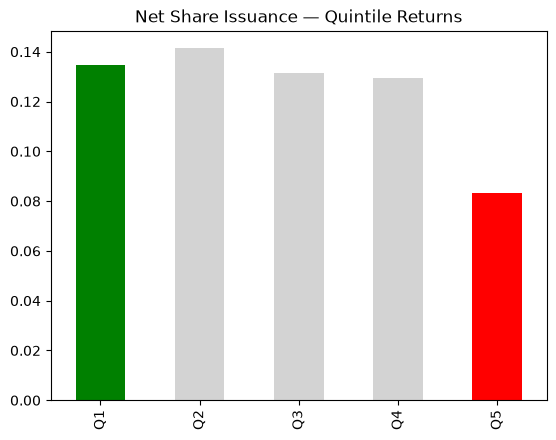

In [11]:
annual = (1 + result.quintile_returns).prod() ** (12 / len(result.quintile_returns)) - 1
annual.plot(kind='bar', color=['green','lightgray','lightgray','lightgray','red'], title='Net Share Issuance — Quintile Returns')
plt.show()

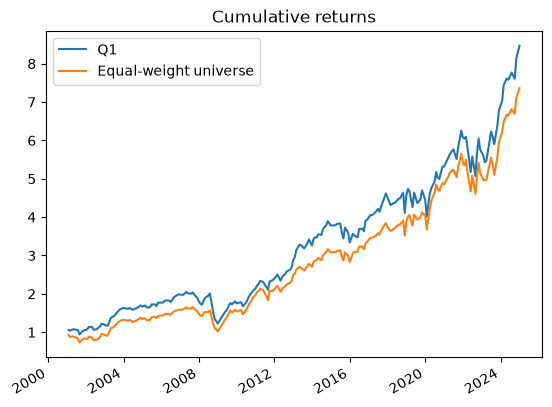

In [12]:
q1 = (1 + result.monthly_returns).cumprod()
ew = result.portfolio_history.groupby('date')['return'].mean().add(1).cumprod()
pd.concat({'Q1': q1, 'Equal-weight universe': ew}, axis=1).plot(title='Cumulative returns')
plt.show()

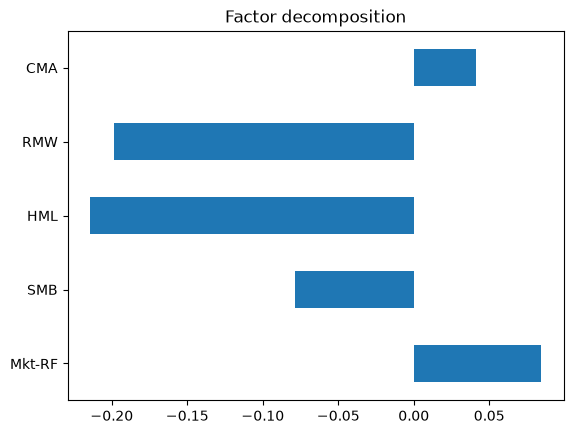

In [13]:
pd.Series(result.betas).plot(kind='barh', title='Factor decomposition')
plt.show()

In [14]:
pd.DataFrame(result.size_terciles or {}).T

""


## Interpretation
What does this mean? Does it match the hypothesis?

## Quality
Quality combines profitability, operating efficiency, leverage, interest coverage, and earnings quality. We expect the signal to load most strongly on RMW and possibly be defensive, especially among smaller firms.

In [15]:
from strategies.quality import run as run_quality
result_quality = run_quality(DB_PATH, START, END)

In [16]:
print('QUALITY ? FULL UNIVERSE')
print('Period:', result_quality.n_months, 'months')
print('Dimensions:', result_quality.dimensions_used)
print('Alpha:', result_quality.alpha_annual, 't/p:', result_quality.alpha_tstat, result_quality.alpha_pvalue)
print('Betas:', result_quality.betas)
print('Lookahead violations:', result_quality.lookahead_violations)

QUALITY ? FULL UNIVERSE
Period: 212 months
Dimensions: {'ART': 148434}
Alpha: 0.1568407650719572 t/p: 3.2553084467270863 0.0013241725413328505
Betas: {'Mkt-RF': -0.03284721804946009, 'SMB': -0.12878650328517047, 'HML': -0.11422818550235259, 'RMW': -0.29154041760484506, 'CMA': 0.08574652051320245}
Lookahead violations: 0


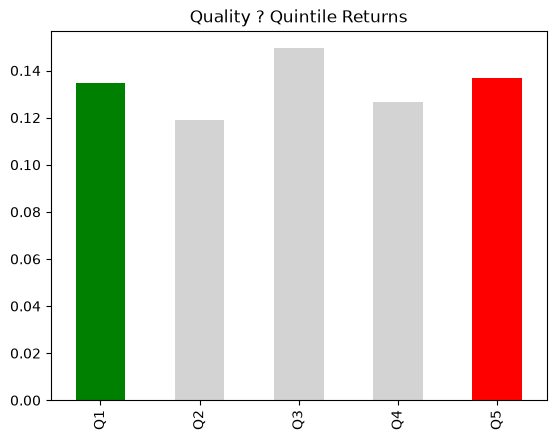

In [17]:
annual_q=(1+result_quality.quintile_returns).prod()**(12/len(result_quality.quintile_returns))-1
annual_q.plot(kind='bar',color=['green','lightgray','lightgray','lightgray','red'],title='Quality ? Quintile Returns'); plt.show()

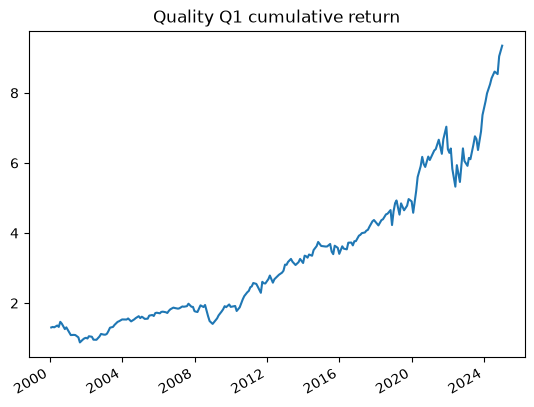

In [18]:
(1+result_quality.monthly_returns).cumprod().plot(title='Quality Q1 cumulative return'); plt.show()

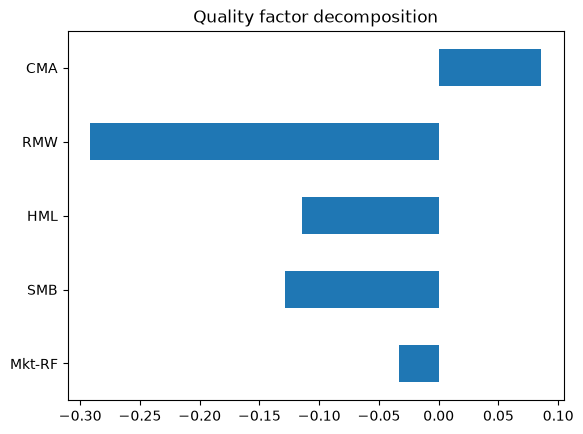

In [19]:
pd.Series(result_quality.betas).plot(kind='barh',title='Quality factor decomposition'); plt.show()

In [20]:
sensitivity=pd.DataFrame(result_quality.sensitivity).T
sensitivity['fragile']=(sensitivity['tstat']-result_quality.alpha_tstat).abs()>0.5
sensitivity

,alpha_annual,tstat,fragile
roe,0.166088,3.158714,False
roa,0.169843,3.342490,False
gm,0.151000,3.188074,False
dte,0.154340,3.439678,False
icr,0.164358,3.367233,False
cfe,0.152371,3.185681,False


In [21]:
pd.DataFrame(result_quality.period_results).T

,alpha_annual,tstat,n_months
2000-2009,0.118264,1.330479,86.0
2010-2019,0.183176,3.084168,84.0
2020-present,0.227153,1.797705,42.0


In [22]:
pd.DataFrame(result_quality.size_terciles or {}).T

""


In [23]:
pd.DataFrame(result_quality.sector_breakdown or {}).T

""


## Quality interpretation
What does this mean? Does it match the hypothesis?

## Accruals
Accruals compare accounting earnings with operating cash flow. We expect low-accrual firms to outperform, with possible stronger effects among smaller firms.

In [24]:
from strategies.accruals import run as run_accruals
result_accruals = run_accruals(DB_PATH, START, END)

In [25]:
print('ACCRUALS ? FULL UNIVERSE')
print('Period:', result_accruals.n_months, 'months')
print('Dimensions:', result_accruals.dimensions_used)
print('Alpha:', result_accruals.alpha_annual, 't/p:', result_accruals.alpha_tstat, result_accruals.alpha_pvalue)
print('Betas:', result_accruals.betas)
print('Lookahead violations:', result_accruals.lookahead_violations)

ACCRUALS ? FULL UNIVERSE
Period: 300 months
Dimensions: {'ART': 148434}
Alpha: 0.1672203164753705 t/p: 3.3147888580728164 0.001032030830398964
Betas: {'Mkt-RF': -0.027201887889854906, 'SMB': -0.20633566804230216, 'HML': -0.025731482470284145, 'RMW': -0.4623484684253685, 'CMA': 0.16267252411295885}
Lookahead violations: 0


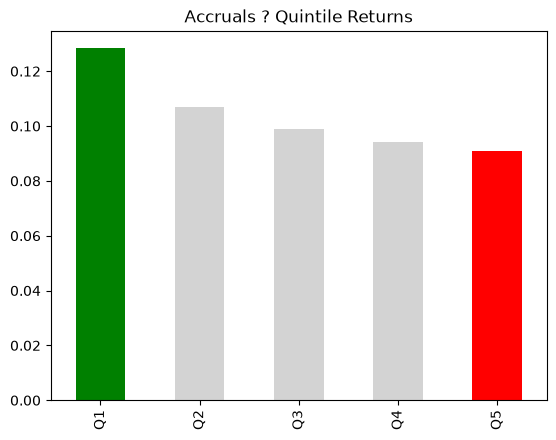

In [26]:
annual_ac=(1+result_accruals.quintile_returns).prod()**(12/len(result_accruals.quintile_returns))-1
annual_ac.plot(kind='bar',color=['green','lightgray','lightgray','lightgray','red'],title='Accruals ? Quintile Returns'); plt.show()

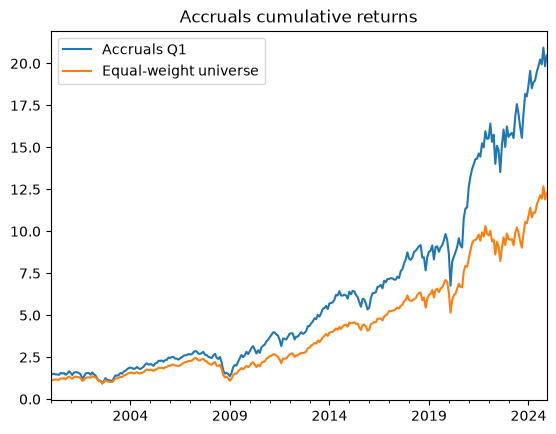

In [27]:
pd.concat({'Accruals Q1':(1+result_accruals.monthly_returns).cumprod(),'Equal-weight universe':result_accruals.portfolio_history.groupby('date')['return'].mean().add(1).cumprod()},axis=1).plot(title='Accruals cumulative returns'); plt.show()

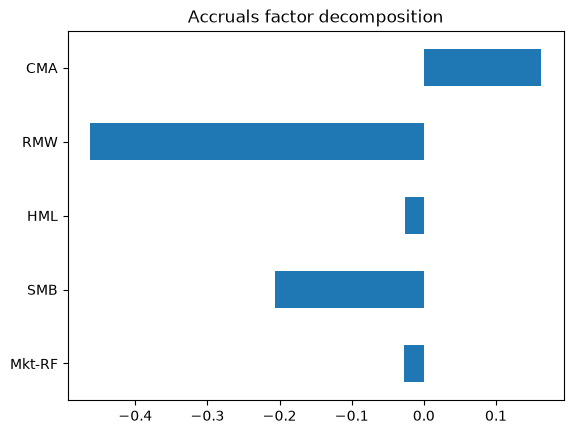

In [28]:
pd.Series(result_accruals.betas).plot(kind='barh',title='Accruals factor decomposition'); plt.show()

In [29]:
pd.DataFrame(result_accruals.period_results).T

,alpha_annual,tstat,n_months
2000-2009,0.182153,1.811232,120.0
2010-2019,0.173858,3.065949,120.0
2020-present,0.198764,1.635443,60.0


In [30]:
pd.DataFrame(result_accruals.size_terciles or {}).T

""


## Three-Signal Summary
This comparison puts the three exploratory signals side by side. It is descriptive only; factor replication and size patterns require interpretation, not automatic promotion.

In [31]:
def _size_effect(result):
    return 'YES' if result.size_terciles else 'N/A'
comparison = pd.DataFrame([
    {'Signal':'Net share issuance','Alpha':result.alpha_annual,'t-stat':result.alpha_tstat,'RMW load':result.betas.get('RMW',float('nan')),'Size effect':_size_effect(result)},
    {'Signal':'Accruals','Alpha':result_accruals.alpha_annual,'t-stat':result_accruals.alpha_tstat,'RMW load':result_accruals.betas.get('RMW',float('nan')),'Size effect':_size_effect(result_accruals)},
    {'Signal':'Quality','Alpha':result_quality.alpha_annual,'t-stat':result_quality.alpha_tstat,'RMW load':result_quality.betas.get('RMW',float('nan')),'Size effect':_size_effect(result_quality)},
]).set_index('Signal')
comparison

,Alpha,t-stat,RMW load,Size effect
Signal,,,,
Net share issuance,0.139890,3.032097,-0.198194,N/A
Accruals,0.167220,3.314789,-0.462348,N/A
Quality,0.156841,3.255308,-0.291540,N/A


Which signals passed t-stat > 2? Which appear primarily explained by factors? Which show the expected size pattern? Record the honest next step for each.